# Energy Resolution Impact on Differential Cross Sections

This notebook compares how **different TOF experimental configurations** affect the
measured differential cross section at a single nominal energy.

The idea is simple: the same angular PDF shape $f(\mu)$ (from ACE at the nominal
energy) is scaled by different total cross sections:

$$\frac{d\sigma}{d\Omega}(\mu) = \frac{\sigma_\text{total} \times f(\mu)}{2\pi}$$

where $\sigma_\text{total}$ is either the **unfolded** (pointwise) value or the
**Gaussian-folded** value for a given TOF configuration. The folding smears
$\sigma(E)$ over a Gaussian window whose width $\sigma_E$ depends on flight path,
time resolution, and neutron energy.

**TOF configurations tested** (from real EXFOR experiments on Fe-56):

| Config | Facility | Flight path (m) | $\Delta t$ FWHM (ns) |
|--------|----------|-----------------|----------------------|
| 1 | Pirovano (nELBE) | 8.3 | 1.0 |
| 2 | Gkatis (GELINA) | 27.037 | 10.0 |
| 3 | Cierjacks (KFK) | 57.0 | 5.47 |
| 4 | Kinney (ORELA) | 40.0 | 8.0 |
| 5 | Boschung (VDG) | 2.75 | 1.5 |
| 6 | Pirovano (GELINA) | 27.037 | 5.0 |

For the configuration with the **widest energy window**, a fan of individual
$f(\mu) \times \sigma(E_i) / (2\pi)$ curves is also drawn to visualise the
spread of cross sections sampled across the resolution kernel.

In [1]:
# ── Configuration ───────────────────────────────────────────────────────────
TARGET = 'Fe56'
TARGET_NAT = 'Fe'
MT = 2

NOMINAL_ENERGY_MEV = 1.4

ACE_PATH = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_81.02c'
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
ENERGY_TOLERANCE = 0.02       # MeV

N_SIGMA = 3.0
N_ENERGY_SAMPLES = 100
NUM_ANGULAR_POINTS = 200
COLORMAP_NAME = 'coolwarm'

# ── JEFF hybrid baseline ────────────────────────────────────────────────────
JEFF_FILE = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt"
KINNEY_SUBENTRY      = "10571002"
SMITH_SUBENTRY       = "10886002"
ENERGY_THRESHOLD_MEV = 2.5
M_PROJ_U = 1.008665   # neutron mass (u)
M_TARG_U = 55.93494   # Fe-56 mass (u)

# ── TOF configurations: (label, flight_path_m, delta_t_ns_FWHM) ────────────
TOF_CONFIGS = [
    ('Pirovano (nELBE)',  8.3,    1.0),
    ('Gkatis (GELINA)',   27.037, 10.0),
    ('Cierjacks (KFK)',   57.0,   5.47),
    ('Kinney (ORELA)',    40.0,   8.0),
    ('Boschung (VDG)',    2.75,   1.5),
    ('Pirovano (GELINA)', 27.037, 5.0),
]

## Imports and Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from numpy.polynomial.legendre import legval

import kika
import kika.exfor as exfor
from kika.exfor import read_all_exfor
from kika.endf import read_endf
from kika.plotting import PlotBuilder
from kika.utils.energy_folding import (
    EnergyFoldingConfig,
    compute_energy_resolution_tof,
    fold_cross_section,
)
from kika.ace.classes.angular_distribution.container import _get_xs_at_energy
from scripts.exfor_utils import build_exfor_cache_from_objects, filter_exfor_with_energy_bin
from scripts.resample_AD import sample_legendre_coefficients

exfor.configure(db_path=EXFOR_DB_PATH)

In [3]:
# ── Load ACE data ────────────────────────────────────────────────────────────
ace = kika.read_ace(ACE_PATH)
print(f'ACE loaded: {ACE_PATH}')

# ── Load EXFOR ───────────────────────────────────────────────────────────────
fe56_experiments = read_all_exfor(target=TARGET, mt=MT, group_by_energy=False)
fe_nat_experiments = read_all_exfor(target=TARGET_NAT, mt=MT, group_by_energy=False)

all_experiments = []
for exp in fe56_experiments.values():
    en = exp.energies(unit='MeV')
    if np.any(np.abs(en - NOMINAL_ENERGY_MEV) <= ENERGY_TOLERANCE):
        all_experiments.append(exp)
for exp in fe_nat_experiments.values():
    en = exp.energies(unit='MeV')
    if np.any(np.abs(en - NOMINAL_ENERGY_MEV) <= ENERGY_TOLERANCE):
        all_experiments.append(exp)

print(f'EXFOR experiments near {NOMINAL_ENERGY_MEV} MeV: {len(all_experiments)}')

ACE loaded: /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_81.02c
EXFOR experiments near 1.4 MeV: 3


In [4]:
# ── JEFF hybrid baseline: c0 from Kinney/Smith EXFOR + ENDF shape ────────────

# 1. Load JEFF MF4 Legendre coefficients at nominal energy
jeff_endf = read_endf(JEFF_FILE)
mt_sec = jeff_endf.get_file(4).sections[MT]
energies_mev = np.array(mt_sec.legendre_energies) / 1e6
target_idx = int(np.argmin(np.abs(energies_mev - NOMINAL_ENERGY_MEV)))
closest_mev = energies_mev[target_idx]
endf_coeffs = np.array(mt_sec.legendre_coefficients[target_idx])  # [a1, ..., a_L]
L_max = len(endf_coeffs)

# Bin boundaries (midpoints of adjacent ENDF grid energies)
bin_lower = (energies_mev[target_idx - 1] + closest_mev) / 2 if target_idx > 0 else 0.0
bin_upper = (closest_mev + energies_mev[target_idx + 1]) / 2 if target_idx < len(energies_mev) - 1 else float('inf')

print(f"JEFF MF4 at {closest_mev:.4f} MeV: L_max={L_max}, bin=[{bin_lower:.4f}, {bin_upper:.4f}] MeV")
print(f"  Coefficients: {endf_coeffs}")

# 2. Select Kinney or Smith subentry based on energy threshold
fit_subentry = KINNEY_SUBENTRY if NOMINAL_ENERGY_MEV < ENERGY_THRESHOLD_MEV else SMITH_SUBENTRY
print(f"  Using subentry {fit_subentry} for fit ({'Kinney' if fit_subentry == KINNEY_SUBENTRY else 'Smith'})")

# 3. Build EXFOR cache and filter for the energy bin
exfor_cache, sorted_energies = build_exfor_cache_from_objects(all_experiments)
fit_df, fit_exp_info, fit_kw, _ = filter_exfor_with_energy_bin(
    exfor_cache=exfor_cache,
    sorted_energies=sorted_energies,
    bin_lower_mev=bin_lower,
    bin_upper_mev=bin_upper,
    target_energy_mev=closest_mev,
    m_proj_u=M_PROJ_U,
    m_targ_u=M_TARG_U,
    dedupe_per_experiment=True,
    normalize_by_n_points=True,
    max_experiment_weight_fraction=0.5,
)

# 4. Post-filter: keep only the selected subentry
if not fit_df.empty:
    entry_str = fit_subentry[:5]
    sub_str = fit_subentry[5:]
    mask = (fit_df['entry'] == entry_str) & (fit_df['subentry'] == sub_str)
    fit_df = fit_df[mask].reset_index(drop=True)
    fit_kw = fit_kw[mask.values] if fit_kw is not None else None

print(f"  EXFOR points for fit: {len(fit_df)}")

# 5. Fit to get c0, then build hybrid coefficients
coef_df, fit_info = sample_legendre_coefficients(
    df=fit_df, value_col="value", unc_col="unc", mu_col="mu",
    degree=L_max, n_samples=1,
    external_weights=fit_kw,
    ridge_lambda=1e-6, rescale_unc_by_chi2=True,
)
c0 = coef_df['c0'].values[0]

hybrid_coeffs = [c0]
for l in range(1, L_max + 1):
    hybrid_coeffs.append(c0 * (2 * l + 1) * endf_coeffs[l - 1])

print(f"  c0 = {c0:.6f} b/sr")
print(f"  chi2_red = {fit_info['chi2_red']:.2f}  (Birge scale {fit_info['scale_factor']:.2f})")

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:90: UserWarning: Skipping MF sections without parsers: [2, 3, 6, 8, 10, 12, 14, 33]. Only parsing: [1, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


JEFF MF4 at 1.4000 MeV: L_max=6, bin=[1.3995, 1.4005] MeV
  Coefficients: [ 0.1056271   0.2108542   0.00285726  0.05376978 -0.00234947  0.00171983]
  Using subentry 10571002 for fit (Kinney)
  EXFOR points for fit: 8
  c0 = 0.162344 b/sr
  chi2_red = 1.87  (Birge scale 1.37)


In [5]:
# ── Compute folded XS for each TOF configuration ────────────────────────────
results = []

for label, L, dt in TOF_CONFIGS:
    config = EnergyFoldingConfig(flight_path_m=L, delta_t_ns=dt, n_sigma=N_SIGMA)
    sigma_E = compute_energy_resolution_tof(NOMINAL_ENERGY_MEV, config)
    folded_xs, unfolded_xs = fold_cross_section(ace, NOMINAL_ENERGY_MEV, MT, sigma_E, N_SIGMA)
    results.append({
        'label': label,
        'flight_path_m': L,
        'delta_t_ns': dt,
        'sigma_E_mev': sigma_E,
        'sigma_E_kev': sigma_E * 1e3,
        'folded_xs': folded_xs,
        'unfolded_xs': unfolded_xs,
    })

# Auto-detect widest resolution window
widest_idx = max(range(len(results)), key=lambda i: results[i]['sigma_E_mev'])

# Print summary table
print(f'{"Config":<22s} {"L (m)":>7s} {"Δt (ns)":>8s} {"σ_E (keV)":>10s} '
      f'{"σ_fold (b)":>10s} {"σ_unfold (b)":>12s} {"Ratio":>6s}')
print('-' * 80)
for i, r in enumerate(results):
    tag = ' ◀ widest' if i == widest_idx else ''
    print(f'{r["label"]:<22s} {r["flight_path_m"]:7.2f} {r["delta_t_ns"]:8.2f} '
          f'{r["sigma_E_kev"]:10.2f} {r["folded_xs"]:10.4f} '
          f'{r["unfolded_xs"]:12.4f} {r["folded_xs"]/r["unfolded_xs"]:6.3f}{tag}')

Config                   L (m)  Δt (ns)  σ_E (keV) σ_fold (b) σ_unfold (b)  Ratio
--------------------------------------------------------------------------------
Pirovano (nELBE)          8.30     1.00       2.34     1.5280       1.0922  1.399
Gkatis (GELINA)          27.04    10.00       7.20     1.8642       1.0922  1.707
Cierjacks (KFK)          57.00     5.47       1.87     1.4489       1.0922  1.327
Kinney (ORELA)           40.00     8.00       3.89     1.6223       1.0922  1.485
Boschung (VDG)            2.75     1.50      10.61     2.0090       1.0922  1.839 ◀ widest
Pirovano (GELINA)        27.04     5.00       3.60     1.6086       1.0922  1.473


In [6]:
# ── Nominal angular shape (PDF, not scaled by XS) ───────────────────────────
nominal_df = ace.angular_distributions.to_dataframe(
    mt=MT,
    energy=NOMINAL_ENERGY_MEV,
    ace=ace,
    num_points=NUM_ANGULAR_POINTS,
    interpolate=True,
    normalize_to_xs=False,
    energy_folding=False,
)
mu = nominal_df['cosine'].values
f_mu = nominal_df['pdf'].values

nominal_xs = _get_xs_at_energy(ace, MT, NOMINAL_ENERGY_MEV)
print(f'Nominal XS at {NOMINAL_ENERGY_MEV} MeV: {nominal_xs:.4f} b')
print(f'Angular PDF shape: {len(mu)} points, mu in [{mu.min():.2f}, {mu.max():.2f}]')

Nominal XS at 1.4 MeV: 1.0922 b
Angular PDF shape: 200 points, mu in [-1.00, 1.00]


## Plot

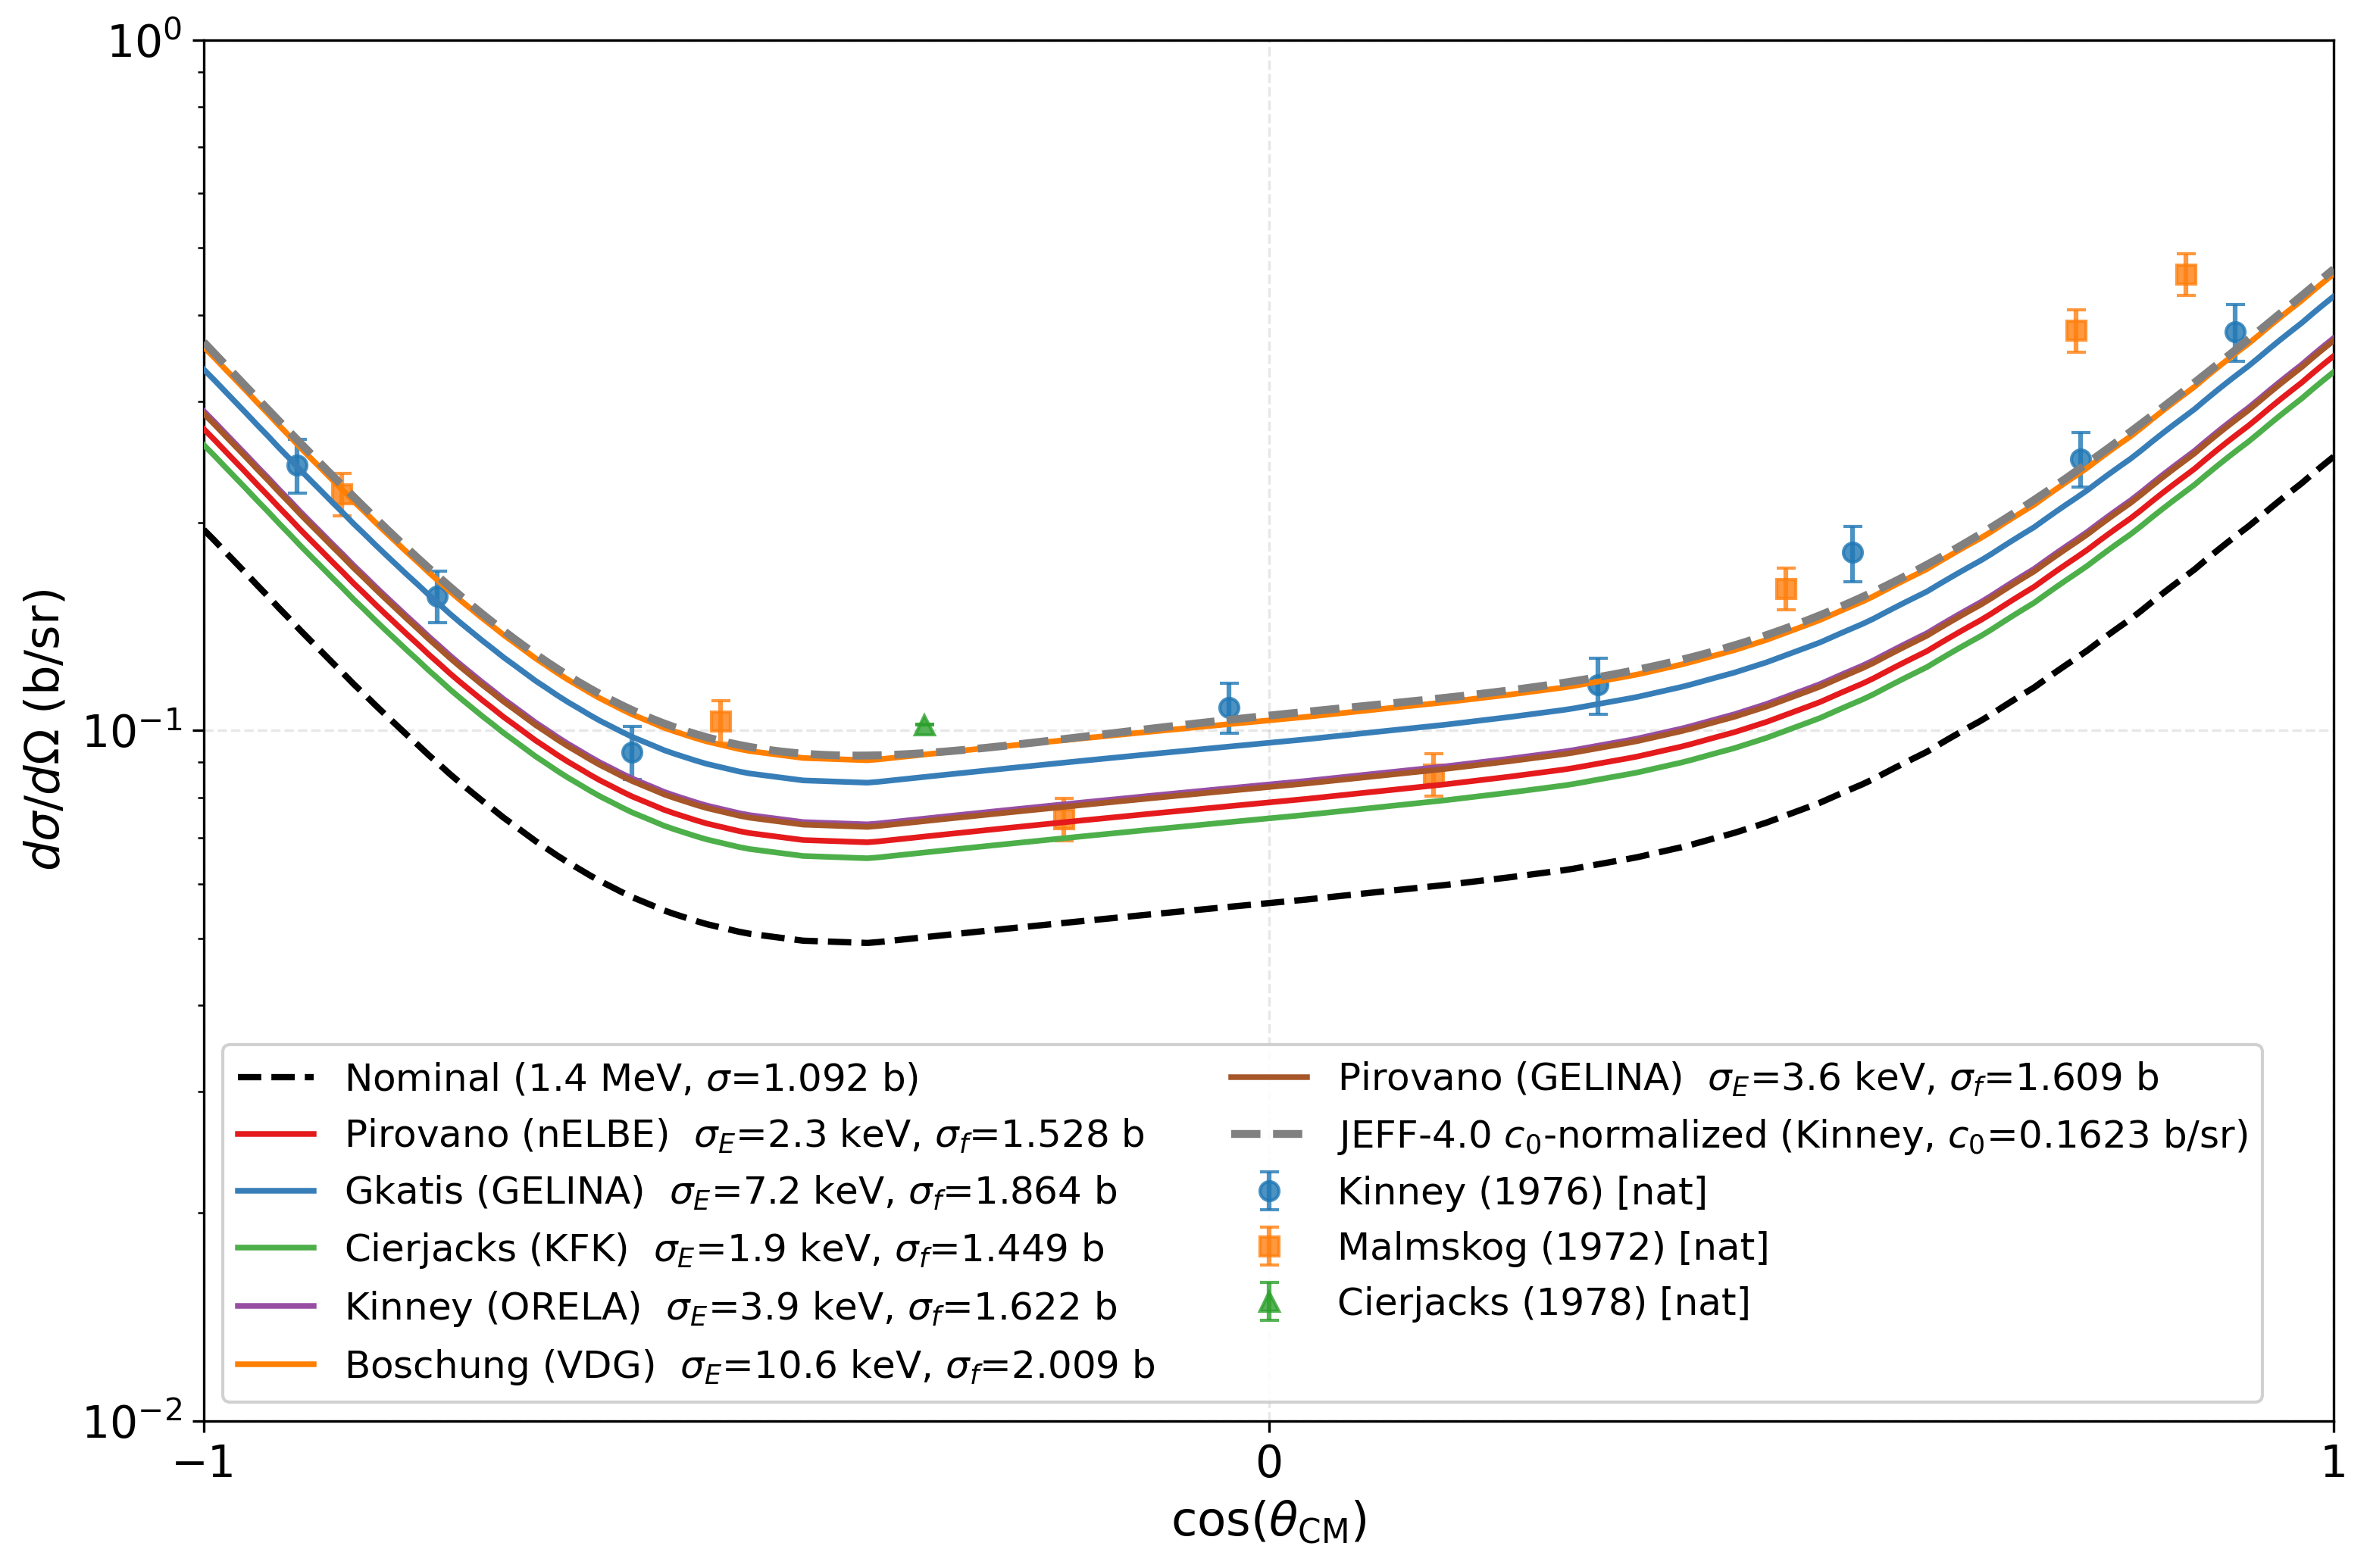

In [8]:
# ── Main figure ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7), dpi=300)

# ── 1. Nominal curve (black dashed) ─────────────────────────────────────────
ax.plot(mu, f_mu * nominal_xs / (2 * np.pi),
        color='black', ls='--', lw=2.0, zorder=5,
        label=f'Nominal ({NOMINAL_ENERGY_MEV} MeV, $\\sigma$={nominal_xs:.3f} b)')

# ── 2. Six folded curves ────────────────────────────────────────────────────
line_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
line_styles = ['-', '-', '-', '-', '-', '-']

for i, r in enumerate(results):
    dsigma = f_mu * r['folded_xs'] / (2 * np.pi)
    ax.plot(mu, dsigma,
            color=line_colors[i], ls=line_styles[i], lw=1.8, zorder=4,
            label=f'{r["label"]}  $\\sigma_E$={r["sigma_E_kev"]:.1f} keV, '
                  f'$\\sigma_f$={r["folded_xs"]:.3f} b')

# ── 3. Shape-normalized JEFF curve (c0 from Kinney/Smith + ENDF shape) ──────
y_fit = legval(mu, hybrid_coeffs)
fit_author = 'Kinney' if fit_subentry == KINNEY_SUBENTRY else 'Smith'
ax.plot(mu, y_fit, color='grey', ls='--', lw=2.5, zorder=6,
        label=f'JEFF-4.0 $c_0$-normalized ({fit_author}, $c_0$={c0:.4f} b/sr)')

# ── 4. EXFOR data overlay ───────────────────────────────────────────────────
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', '<', '>']
tab_colors = plt.cm.tab10.colors
for idx, exp in enumerate(all_experiments):
    plot_data = exp.to_plot_data(
        energy=NOMINAL_ENERGY_MEV,
        tolerance=ENERGY_TOLERANCE,
        frame='CM',
        angle_unit='cos',
        cross_section_unit='b/sr',
        uncertainty=True,
        include_natural_tag=True,
        marker=markers[idx % len(markers)],
        color=tab_colors[idx % len(tab_colors)],
        markersize=6,
        capsize=3,
        alpha=0.8,
    )
    if plot_data is not None:
        builder = PlotBuilder(ax=ax)
        builder.add_data(plot_data)
        builder.build()

# ── 5. Axes formatting ──────────────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlim(-1, 1)
ax.set_ylim(0.01, 1)
ax.set_xlabel(r'$\cos(\theta_\mathrm{CM})$', fontsize=15)
ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=15)
ax.legend(loc='lower left', fontsize=12, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

## Observations

- **Boschung (VDG)** has the widest energy resolution ($\sigma_E$) because the
  very short flight path (2.75 m) amplifies the $\Delta t / t$ ratio despite
  a modest time resolution. Its fan shows the largest spread in $d\sigma/d\Omega$.

- **Cierjacks (KFK)** and **Pirovano (GELINA)** have narrow resolutions due to
  long flight paths (57 m and 27 m respectively) combined with moderate $\Delta t$.
  Their folded curves lie closest to the nominal (unfolded) curve.

- The **folded cross section** can be higher or lower than the nominal value
  depending on the local curvature of $\sigma(E)$: near resonance peaks the
  Gaussian kernel samples the flanks, pulling the average down; in valleys,
  it pulls the average up.

- All six folded curves share the **same angular shape** $f(\mu)$; the only
  difference is the scalar $\sigma_\text{folded}$ multiplying it. This isolates
  the pure effect of energy resolution on the total cross section normalisation.